#Workplace Mental Health Risk Prediction

**Dataset:** OSMI Mental Health in Tech Survey (2014 + 2016)

#Clone GitHub

In [6]:
import os

REPO_URL = "https://github.com/Chandhana-sanoj/workplace-mental-health-risk-prediction.git"
REPO_NAME = "workplace-mental-health-risk-prediction"

if not os.path.exists(REPO_NAME):
    !git clone {REPO_URL}

BASE = f"{REPO_NAME}/data/"

print("Repo ready.")

Repo ready.


#Importing Libraries

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

from scipy.stats import chi2_contingency
from sklearn.preprocessing import OrdinalEncoder,LabelEncoder, OneHotEncoder, MinMaxScaler
from sklearn.model_selection import train_test_split, GridSearchCV
from imblearn.over_sampling import SMOTE

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

try:
    from xgboost import XGBClassifier
except ImportError:
    import subprocess
    subprocess.run(["pip", "install", "xgboost", "-q"])
    from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report
)

import pickle
import os

from sklearn.model_selection import GridSearchCV

import warnings
warnings.filterwarnings("ignore")
pd.set_option('display.max_columns', None)

print("All libraries loaded successfully.")


All libraries loaded successfully.


#Data Loading & Understanding

In [8]:
df_2014_raw = pd.read_csv("workplace-mental-health-risk-prediction/data/osmi_mental_health_2014.csv")
df_2016_raw = pd.read_csv("workplace-mental-health-risk-prediction/data/osmi_mental_health_2016.csv")

df_2014 = df_2014_raw.copy()
df_2016 = df_2016_raw.copy()

print("2014 shape:", df_2014.shape)
print("2016 shape:", df_2016.shape)

2014 shape: (1259, 27)
2016 shape: (1433, 63)


## Column Alignment

In [9]:
# Checking target column in both years

print("2014 — target (treatment):")
print(df_2014['treatment'].value_counts())

print()
target_col_2016 = 'Have you ever sought treatment for a mental health issue from a mental health professional?'
print("2016 — target (full question):")
print(df_2016[target_col_2016].value_counts())

2014 — target (treatment):
treatment
Yes    637
No     622
Name: count, dtype: int64

2016 — target (full question):
Have you ever sought treatment for a mental health issue from a mental health professional?
1    839
0    594
Name: count, dtype: int64


In [10]:
# Define Core Feature Mapping
# Format: '2016 full question' : '2014 short name'

mapping = {
    'Have you ever sought treatment for a mental health issue from a mental health professional?' : 'treatment',
    'What is your age?'                                                                           : 'Age',
    'What is your gender?'                                                                        : 'Gender',
    'Are you self-employed?'                                                                      : 'self_employed',
    'How many employees does your company or organization have?'                                  : 'no_employees',
    'Is your employer primarily a tech company/organization?'                                     : 'tech_company',
    'Do you work remotely?'                                                                       : 'remote_work',
    'Does your employer provide mental health benefits as part of healthcare coverage?'           : 'benefits',
    'Do you know the options for mental health care available under your employer-provided coverage?' : 'care_options',
    'Does your employer offer resources to learn more about mental health concerns and options for seeking help?' : 'seek_help',
    'Is your anonymity protected if you choose to take advantage of mental health or substance abuse treatment resources provided by your employer?' : 'anonymity',
    'Do you think that discussing a mental health disorder with your employer would have negative consequences?' : 'mental_health_consequence',
    'Do you have a family history of mental illness?'                                             : 'family_history',
    'Would you feel comfortable discussing a mental health disorder with your coworkers?'         : 'coworkers',
    'Would you feel comfortable discussing a mental health disorder with your direct supervisor(s)?': 'supervisor',
    'Have you observed or experienced an unsupportive or badly handled response to a mental health issue in your current or previous workplace?' : 'obs_consequence',
}

print(f"Total mappable columns: {len(mapping)}")
print("\nCore Feature Set:")
for i, name in enumerate(mapping.values(), 1):
    print(f"  {i:2}. {name}")

Total mappable columns: 16

Core Feature Set:
   1. treatment
   2. Age
   3. Gender
   4. self_employed
   5. no_employees
   6. tech_company
   7. remote_work
   8. benefits
   9. care_options
  10. seek_help
  11. anonymity
  12. mental_health_consequence
  13. family_history
  14. coworkers
  15. supervisor
  16. obs_consequence


In [11]:
# Checking value alignment BEFORE renaming

checks = [
    ('self_employed',  'Are you self-employed?'),
    ('remote_work',    'Do you work remotely?'),
    ('benefits',       'Does your employer provide mental health benefits as part of healthcare coverage?'),
    ('family_history', 'Do you have a family history of mental illness?'),
    ('tech_company',   'Is your employer primarily a tech company/organization?'),
    ('anonymity',      'Is your anonymity protected if you choose to take advantage of mental health or substance abuse treatment resources provided by your employer?'),
]

print("VALUE ALIGNMENT CHECK")

for col_2014, col_2016 in checks:
    print(f"\n── {col_2014}")
    print(f"  2014: {sorted(df_2014[col_2014].dropna().unique())}")
    print(f"  2016: {sorted(df_2016[col_2016].dropna().unique())}")

VALUE ALIGNMENT CHECK

── self_employed
  2014: ['No', 'Yes']
  2016: [np.int64(0), np.int64(1)]

── remote_work
  2014: ['No', 'Yes']
  2016: ['Always', 'Never', 'Sometimes']

── benefits
  2014: ["Don't know", 'No', 'Yes']
  2016: ["I don't know", 'No', 'Not eligible for coverage / N/A', 'Yes']

── family_history
  2014: ['No', 'Yes']
  2016: ["I don't know", 'No', 'Yes']

── tech_company
  2014: ['No', 'Yes']
  2016: [np.float64(0.0), np.float64(1.0)]

── anonymity
  2014: ["Don't know", 'No', 'Yes']
  2016: ["I don't know", 'No', 'Yes']


In [12]:
# Renameing 2016 columns to match 2014

df_2016 = df_2016.rename(columns=mapping)

print("2016 columns after renaming:")
print([col for col in mapping.values()])
print("\nConfirm — do renamed columns exist in df_2016?")
for col in mapping.values():
    exists = col in df_2016.columns
    print(f"  {col:35s} → {'yes' if exists else 'MISSING'}")

2016 columns after renaming:
['treatment', 'Age', 'Gender', 'self_employed', 'no_employees', 'tech_company', 'remote_work', 'benefits', 'care_options', 'seek_help', 'anonymity', 'mental_health_consequence', 'family_history', 'coworkers', 'supervisor', 'obs_consequence']

Confirm — do renamed columns exist in df_2016?
  treatment                           → yes
  Age                                 → yes
  Gender                              → yes
  self_employed                       → yes
  no_employees                        → yes
  tech_company                        → yes
  remote_work                         → yes
  benefits                            → yes
  care_options                        → yes
  seek_help                           → yes
  anonymity                           → yes
  mental_health_consequence           → yes
  family_history                      → yes
  coworkers                           → yes
  supervisor                          → yes
  obs_consequence    

In [13]:
# Selecting only core columns from each dataset

core_cols = list(mapping.values())

df_2014 = df_2014[core_cols]
df_2016 = df_2016[core_cols]

print("2014 after column selection:", df_2014.shape)
print("2016 after column selection:", df_2016.shape)

2014 after column selection: (1259, 16)
2016 after column selection: (1433, 16)


# Combine Datasets

In [14]:
# Adding year column before combining

df_2014['survey_year'] = 2014
df_2016['survey_year'] = 2016

In [15]:
# Combine


df = pd.concat([df_2014, df_2016], ignore_index=True)

print(df.duplicated().sum())
df = df.drop_duplicates()

print("Combined dataset shape:", df.shape)
print(f"\nRows from 2014: {(df['survey_year'] == 2014).sum()}")
print(f"Rows from 2016: {(df['survey_year'] == 2016).sum()}")
print(f"\nTarget balance after combining:")
print(df['treatment'].value_counts())

17
Combined dataset shape: (2675, 17)

Rows from 2014: 1251
Rows from 2016: 1424

Target balance after combining:
treatment
1      834
Yes    635
No     616
0      590
Name: count, dtype: int64


##Standardize key columns

In [16]:
# Fix 1: Target column

df['treatment'] = df['treatment'].astype(str).str.strip().str.lower()
df['treatment'] = df['treatment'].map({
    'yes': 1,
    'no': 0,
    '1': 1,
    '1.0': 1,
    '0': 0,
    '0.0': 0
})

print(df['treatment'].value_counts())
print(f"Nulls: {df['treatment'].isnull().sum()}")

treatment
1    1469
0    1206
Name: count, dtype: int64
Nulls: 0


In [17]:
# Fix 2: self_employed

df['self_employed'] = df['self_employed'].astype(str).str.strip().str.lower()
df['self_employed'] = df['self_employed'].map({
    'yes': 1, 'no': 0,
    '1': 1,   '0': 0,
    '1.0': 1, '0.0': 0
})

print(df['self_employed'].value_counts())


self_employed
0.0    2232
1.0     425
Name: count, dtype: int64


In [18]:
# Fix 3: tech_company

df['tech_company'] = df['tech_company'].astype(str).str.strip().str.lower()
df['tech_company'] = df['tech_company'].map({
    'yes': 1, 'no': 0,
    '1': 1,   '0': 0,
    '1.0': 1, '0.0': 0
})

print(df['tech_company'].value_counts())

tech_company
1.0    1905
0.0     490
Name: count, dtype: int64


In [19]:
# Fix 4: remote_work

df['remote_work'] = df['remote_work'].astype(str).str.strip().str.lower()

def fix_remote(val):
    if val in ['yes', 'always', 'sometimes']:
        return 1
    elif val in ['no', 'never']:
        return 0
    else:
        return np.nan

df['remote_work'] = df['remote_work'].apply(fix_remote)

print("remote_work after fix:")
print(df['remote_work'].value_counts())
print(f"Nulls: {df['remote_work'].isnull().sum()}")

remote_work after fix:
remote_work
1    1467
0    1208
Name: count, dtype: int64
Nulls: 0


In [20]:
# Fix 5: benefits

def fix_three_way(val):
    val = str(val).strip().lower()
    if val == 'yes':
        return 1
    elif val == 'no':
        return 0
    else:
        return np.nan  # Don't know / Not eligible handled later

df['benefits']  = df['benefits'].apply(fix_three_way)
df['anonymity'] = df['anonymity'].apply(fix_three_way)

print("benefits after fix:")
print(df['benefits'].value_counts())
print(f"Nulls: {df['benefits'].isnull().sum()}")

print("\nanonymity after fix:")
print(df['anonymity'].value_counts())
print(f"Nulls: {df['anonymity'].isnull().sum()}")

benefits after fix:
benefits
1.0    1005
0.0     581
Name: count, dtype: int64
Nulls: 1089

anonymity after fix:
anonymity
1.0    693
0.0    147
Name: count, dtype: int64
Nulls: 1835


In [21]:
# Fix 6: family_history

df['family_history'] = df['family_history'].apply(fix_three_way)

print("\nfamily_history after fix:")
print(df['family_history'].value_counts())
print(f"Nulls: {df['family_history'].isnull().sum()}")


family_history after fix:
family_history
0.0    1246
1.0    1155
Name: count, dtype: int64
Nulls: 274


In [22]:
# Fix 7: Age

df['Age'] = pd.to_numeric(df['Age'], errors='coerce')

print("Before Age filter:")
print(f"  Min: {df['Age'].min()}, Max: {df['Age'].max()}")
print(f"  Nulls: {df['Age'].isnull().sum()}")

df = df[(df['Age'] >= 18) & (df['Age'] <= 75)]

print("\nAfter Age filter:")
print(f"  Min: {df['Age'].min()}, Max: {df['Age'].max()}")
print(f"  Rows remaining: {len(df)}")

Before Age filter:
  Min: -1726, Max: 99999999999
  Nulls: 0

After Age filter:
  Min: 18, Max: 74
  Rows remaining: 2662


In [23]:
# Fix 8: Gender

def clean_gender(val):
    if pd.isnull(val):
        return 'Other'
    val = str(val).lower().strip()
    if val in ['male', 'm', 'man', 'cis male', 'male (cis)',
               'maile', 'mal', 'make', 'msle', 'cis man',
               'malr', 'mail', 'm ale']:
        return 'Male'
    elif val in ['female', 'f', 'woman', 'cis female', 'femake',
                 'female (cis)', 'femail', 'cis-female/femme',
                 'female (trans)', 'trans woman', 'f m']:
        return 'Female'
    else:
        return 'Other'

df['Gender'] = df['Gender'].apply(clean_gender)

print("Gender after cleaning:")
print(df['Gender'].value_counts())

Gender after cleaning:
Gender
Male      2015
Female     580
Other       67
Name: count, dtype: int64


In [24]:
# Fix 9: Fill remaining missing values

print("Nulls before filling:")
print(df.isnull().sum()[df.isnull().sum() > 0])

# Binary columns — fill with mode (most common value)
binary_cols = ['self_employed', 'remote_work', 'tech_company',
               'benefits', 'anonymity', 'family_history']

for col in binary_cols:
    mode_val = df[col].mode()[0]
    df[col] = df[col].fillna(mode_val)
    print(f"  {col}: filled nulls with mode = {mode_val}")

# Other categorical columns
cat_cols = ['no_employees', 'care_options', 'seek_help',
            'mental_health_consequence', 'coworkers',
            'supervisor', 'obs_consequence']

for col in cat_cols:
    if col in df.columns:
        df[col] = df[col].fillna(df[col].mode()[0])

print("\nNulls after filling:")
remaining = df.isnull().sum()[df.isnull().sum() > 0]
print(remaining if len(remaining) > 0 else "None — all clean!")

Nulls before filling:
self_employed                  18
no_employees                  279
tech_company                  279
benefits                     1087
care_options                  410
seek_help                     279
anonymity                    1827
mental_health_consequence     279
family_history                273
coworkers                     279
supervisor                    279
obs_consequence                88
dtype: int64
  self_employed: filled nulls with mode = 0.0
  remote_work: filled nulls with mode = 1
  tech_company: filled nulls with mode = 1.0
  benefits: filled nulls with mode = 1.0
  anonymity: filled nulls with mode = 1.0
  family_history: filled nulls with mode = 0.0

Nulls after filling:
None — all clean!


In [25]:
# FINAL DATASET SUMMARY

print(f"Shape: {df.shape}")
print(f"\nTarget balance:")
print(df['treatment'].value_counts())
print(f"\nData types:")
print(df.dtypes)
print(f"\nAny nulls remaining: {df.isnull().sum().sum()}")

# Save cleaned combined file

df.to_csv("workplace-mental-health-risk-prediction/data/osmi_combined_cleaned.csv", index=False)
print("\nSaved: osmi_combined_cleaned.csv")

Shape: (2662, 17)

Target balance:
treatment
1    1462
0    1200
Name: count, dtype: int64

Data types:
treatment                      int64
Age                            int64
Gender                        object
self_employed                float64
no_employees                  object
tech_company                 float64
remote_work                    int64
benefits                     float64
care_options                  object
seek_help                     object
anonymity                    float64
mental_health_consequence     object
family_history               float64
coworkers                     object
supervisor                    object
obs_consequence               object
survey_year                    int64
dtype: object

Any nulls remaining: 0

Saved: osmi_combined_cleaned.csv


In [26]:
# Convert float binary columns to int

float_binary_cols = ['self_employed', 'tech_company',
                     'benefits', 'anonymity', 'family_history']

for col in float_binary_cols:
    df[col] = df[col].astype(int)

print("Data types after fix:")
print(df.dtypes)
print(f"\nFinal shape: {df.shape}")
print(f"Nulls: {df.isnull().sum().sum()}")

# Overwrite saved file

df.to_csv("workplace-mental-health-risk-prediction/data/osmi_combined_cleaned.csv", index=False)
print("\nFile updated: osmi_combined_cleaned.csv")

Data types after fix:
treatment                     int64
Age                           int64
Gender                       object
self_employed                 int64
no_employees                 object
tech_company                  int64
remote_work                   int64
benefits                      int64
care_options                 object
seek_help                    object
anonymity                     int64
mental_health_consequence    object
family_history                int64
coworkers                    object
supervisor                   object
obs_consequence              object
survey_year                   int64
dtype: object

Final shape: (2662, 17)
Nulls: 0

File updated: osmi_combined_cleaned.csv


##Final Dataset

In [27]:
df = pd.read_csv("workplace-mental-health-risk-prediction/data/osmi_combined_cleaned.csv")
print("Shape:", df.shape)
print("\nTarget balance:")
print(df['treatment'].value_counts())
print(f"\nColumns: {df.columns.tolist()}")

Shape: (2662, 17)

Target balance:
treatment
1    1462
0    1200
Name: count, dtype: int64

Columns: ['treatment', 'Age', 'Gender', 'self_employed', 'no_employees', 'tech_company', 'remote_work', 'benefits', 'care_options', 'seek_help', 'anonymity', 'mental_health_consequence', 'family_history', 'coworkers', 'supervisor', 'obs_consequence', 'survey_year']


# Data Quality Assessment

In [28]:
print("Dataset Shape")
print(df.shape)

print("\nMissing Values")
print(df.isnull().sum())

print("\nDuplicate Rows")
print(df.duplicated().sum())

print("\nData Types")
print(df.dtypes)

Dataset Shape
(2662, 17)

Missing Values
treatment                    0
Age                          0
Gender                       0
self_employed                0
no_employees                 0
tech_company                 0
remote_work                  0
benefits                     0
care_options                 0
seek_help                    0
anonymity                    0
mental_health_consequence    0
family_history               0
coworkers                    0
supervisor                   0
obs_consequence              0
survey_year                  0
dtype: int64

Duplicate Rows
55

Data Types
treatment                     int64
Age                           int64
Gender                       object
self_employed                 int64
no_employees                 object
tech_company                  int64
remote_work                   int64
benefits                      int64
care_options                 object
seek_help                    object
anonymity                   

In [52]:
print("Rows before:", df.shape)

df_no_dup = df.drop_duplicates()

print("Rows after:", df_no_dup.shape)

Rows before: (2662, 17)
Rows after: (2607, 17)


#Exploratory Data Analysis (EDA)

##Plot 1: Target Distribution

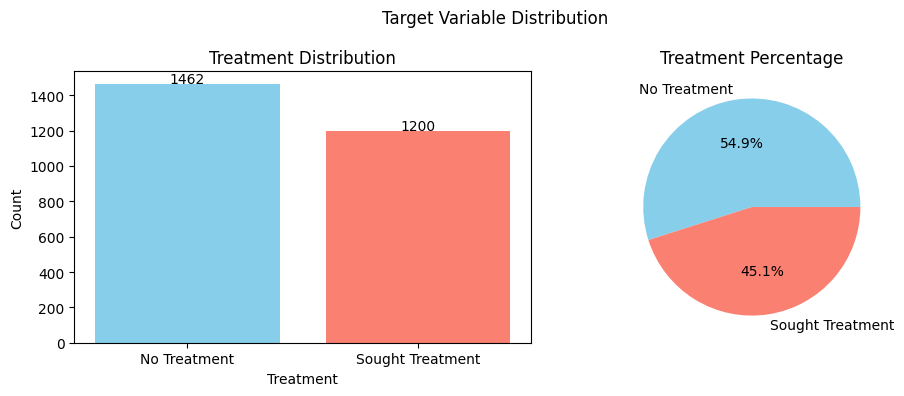

In [29]:
fig, ax = plt.subplots(1, 2, figsize=(10, 4))

# Target counts
counts = df['treatment'].value_counts()

# Bar chart
ax[0].bar(
    ['No Treatment', 'Sought Treatment'],
    counts.values,
    color=['skyblue', 'salmon'])

ax[0].set_title("Treatment Distribution")
ax[0].set_xlabel("Treatment")
ax[0].set_ylabel("Count")

for i, value in enumerate(counts.values):
    ax[0].text(
        i,value + 5,
        str(value),
        ha='center')

# Pie chart
ax[1].pie(
    counts.values,
    labels=['No Treatment', 'Sought Treatment'],
    autopct='%1.1f%%',
    colors=['skyblue', 'salmon'])

ax[1].set_title("Treatment Percentage")

plt.suptitle("Target Variable Distribution")
plt.tight_layout()
plt.savefig("workplace-mental-health-risk-prediction/reports/plot1_target_distribution.png",dpi=150)
plt.show()

In [30]:
# Dataset is approximately balanced (~55/45)
# Large imbalance is not present
# SMOTE likely not required

## Plot 2: Family History vs Treatment

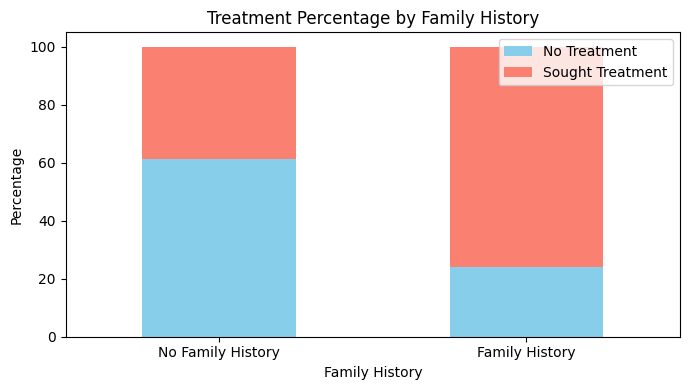

In [31]:
fig, ax = plt.subplots(figsize=(7, 4))

# Group data
family_treat = df.groupby(
    ['family_history', 'treatment']).size().unstack()

family_treat.index = [
    'No Family History',
    'Family History']

family_treat.columns = [
    'No Treatment',
    'Sought Treatment']

# Percentage chart
family_pct = (
    family_treat.div(
        family_treat.sum(axis=1),axis=0) * 100)

family_pct.plot(
    kind='bar',
    stacked=True,
    ax=ax,
    color=['skyblue', 'salmon'])

ax.set_title("Treatment Percentage by Family History")
ax.set_xlabel("Family History")
ax.set_ylabel("Percentage")
ax.tick_params(axis='x',rotation=0)

plt.tight_layout()

plt.savefig("workplace-mental-health-risk-prediction/reports/plot2_family_history.png",dpi=150)
plt.show()

In [32]:
#Employees with family history of mental illness are significantly more likely to seek treatment

##Plot 3: Benefits vs Treatment

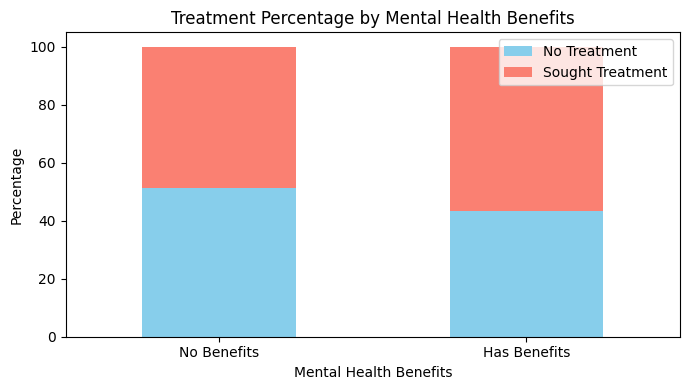

In [33]:
fig, ax = plt.subplots(figsize=(7, 4))

# Group data
benefits_treat = df.groupby(['benefits', 'treatment']).size().unstack()

benefits_treat.index = [
    'No Benefits',
    'Has Benefits']

benefits_treat.columns = [
    'No Treatment',
    'Sought Treatment']

# Convert to percentages
benefits_pct = (benefits_treat.div(benefits_treat.sum(axis=1),axis=0) * 100)

# Plot
benefits_pct.plot(
    kind='bar',
    stacked=True,
    ax=ax,
    color=['skyblue', 'salmon'])

ax.set_title("Treatment Percentage by Mental Health Benefits")
ax.set_xlabel("Mental Health Benefits")
ax.set_ylabel("Percentage")
ax.tick_params(axis='x',rotation=0)

plt.tight_layout()
plt.savefig("workplace-mental-health-risk-prediction/reports/plot3_benefits.png",dpi=150)
plt.show()

In [34]:
#Employees with mental health benefits are more likely to seek treatment — access to resources encourages help-seeking behaviour

##Plot 4: Gender vs Treatment

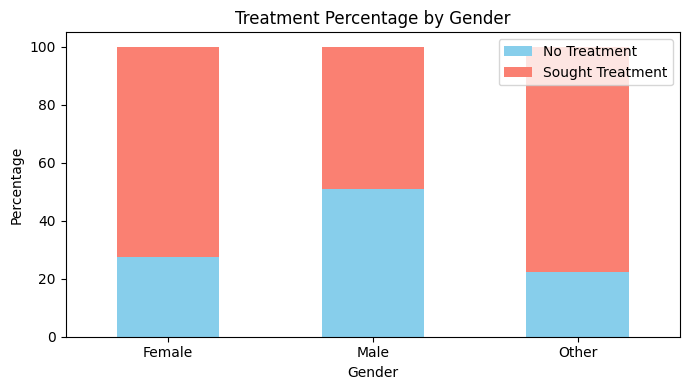

In [35]:
fig, ax = plt.subplots(figsize=(7, 4))

# Group gender and treatment
gender_treat = df.groupby(['Gender', 'treatment']).size().unstack()

gender_treat.columns = [
    'No Treatment',
    'Sought Treatment']

# Convert to percentage
gender_pct = (gender_treat.div(gender_treat.sum(axis=1),axis=0) * 100)

# Plot
gender_pct.plot(
    kind='bar',
    stacked=True,
    ax=ax,
    color=['skyblue', 'salmon'])

ax.set_title("Treatment Percentage by Gender")
ax.set_xlabel("Gender")
ax.set_ylabel("Percentage")
ax.tick_params(axis='x',rotation=0)

plt.tight_layout()

plt.savefig("workplace-mental-health-risk-prediction/reports/plot4_gender.png",dpi=150)
plt.show()

In [36]:
#Female respondents show higher treatment-seeking rates than male.
#'Other' gender category shows highest rates — may reflect awareness

##Plot 5: Remote Work vs Treatment

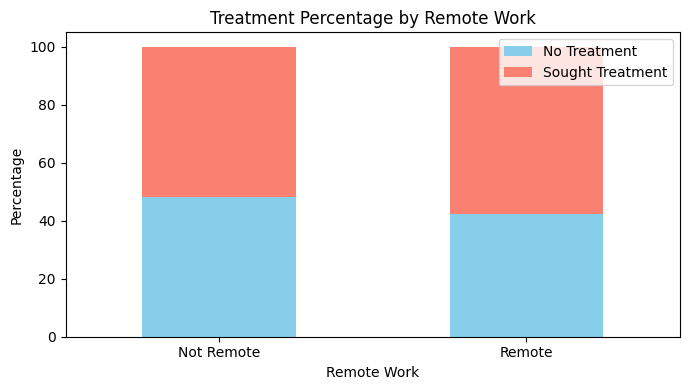

In [37]:
fig, ax = plt.subplots(figsize=(7, 4))

# Group remote work and treatment
remote_treat = df.groupby(['remote_work', 'treatment']).size().unstack()

remote_treat.index = [
    'Not Remote',
    'Remote']

remote_treat.columns = [
    'No Treatment',
    'Sought Treatment']

# Convert to percentage
remote_pct = (remote_treat.div(remote_treat.sum(axis=1),axis=0) * 100)

# Plot
remote_pct.plot(
    kind='bar',
    stacked=True,
    ax=ax,
    color=['skyblue', 'salmon'])

ax.set_title("Treatment Percentage by Remote Work")
ax.set_xlabel("Remote Work")
ax.set_ylabel("Percentage")
ax.tick_params(axis='x',rotation=0)

plt.tight_layout()
plt.savefig("workplace-mental-health-risk-prediction/reports/plot5_remote_work.png",dpi=150)
plt.show()

In [38]:
#Remote work shows similar treatment rates to non-remote

##Plot 6: Anonymity vs Treatment

In [39]:
#anonymity:Does the company protect employee privacy if they seek mental health treatment/support?

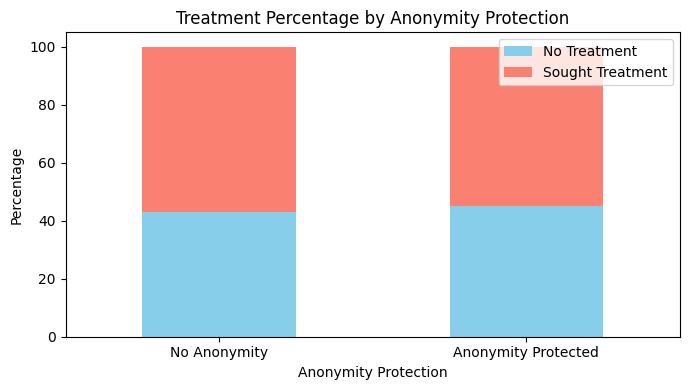

In [40]:
fig, ax = plt.subplots(figsize=(7, 4))

# Group anonymity and treatment
anon_treat = df.groupby(['anonymity', 'treatment']).size().unstack()

anon_treat.index = [
    'No Anonymity',
    'Anonymity Protected']

anon_treat.columns = [
    'No Treatment',
    'Sought Treatment']

# Convert to percentages
anon_pct = (anon_treat.div(anon_treat.sum(axis=1),axis=0) * 100)

# Plot
anon_pct.plot(
    kind='bar',
    stacked=True,
    ax=ax,
    color=['skyblue', 'salmon'])

ax.set_title("Treatment Percentage by Anonymity Protection")
ax.set_xlabel("Anonymity Protection")
ax.set_ylabel("Percentage")
ax.tick_params(axis='x',rotation=0)

plt.tight_layout()
plt.savefig("workplace-mental-health-risk-prediction/reports/plot6_anonymity.png",dpi=150)
plt.show()

In [41]:
# Treatment percentages appear similar across anonymity groups.
# Workplace anonymity protection may have limited predictive influence.

##Plot 7: Age Distribution

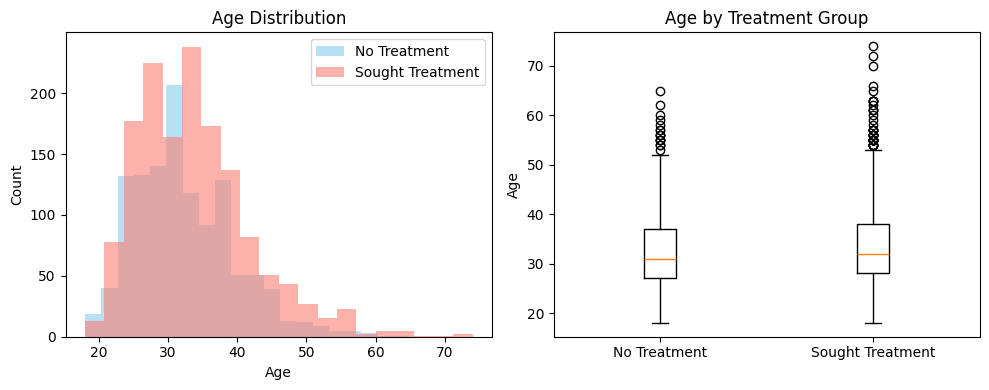

In [42]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Histogram
for treatment_val, label, color in [
    (0, 'No Treatment', 'skyblue'),
    (1, 'Sought Treatment', 'salmon')]:

    axes[0].hist(
        df[df['treatment'] == treatment_val]['Age'],
        bins=20,
        alpha=0.6,
        label=label,
        color=color)

axes[0].set_title("Age Distribution")
axes[0].set_xlabel("Age")
axes[0].set_ylabel("Count")
axes[0].legend()

# Boxplot
axes[1].boxplot(
    [
        df[df['treatment'] == 0]['Age'],
        df[df['treatment'] == 1]['Age']
    ],
    labels=[
        'No Treatment',
        'Sought Treatment'
    ]
)

axes[1].set_title("Age by Treatment Group")
axes[1].set_ylabel("Age")

plt.tight_layout()
plt.savefig("workplace-mental-health-risk-prediction/reports/plot7_age.png",dpi=150)
plt.show()

In [43]:
#Compared age distributions across groups
#Age distributions largely overlap between groups

##Plot 8: Correlation Heatmap

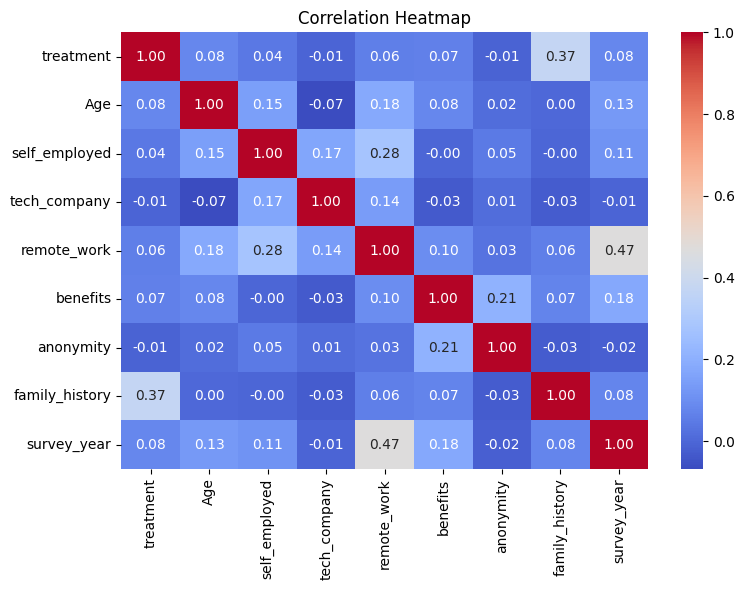

In [44]:
# Numeric columns
numeric_cols = [
    'treatment',
    'Age',
    'self_employed',
    'tech_company',
    'remote_work',
    'benefits',
    'anonymity',
    'family_history',
    'survey_year']

# Correlation matrix
corr_matrix = df[numeric_cols].corr()

plt.figure(figsize=(8, 6))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm')

plt.title("Correlation Heatmap")
plt.tight_layout()
plt.savefig("workplace-mental-health-risk-prediction/reports/plot8_correlation_heatmap.png",dpi=150)
plt.show()

In [45]:
# family_history shows strongest correlation with treatment (0.37).
# Most other numeric features show weak linear relationships.

##Chi-Square Statistical Test

In [46]:
# Chi-square test — which categorical features are statistically significant predictors of treatment?

In [47]:
cat_features = ['self_employed', 'tech_company', 'remote_work',
                'benefits', 'anonymity', 'family_history',
                'Gender', 'no_employees', 'care_options',
                'seek_help', 'mental_health_consequence',
                'coworkers', 'supervisor', 'obs_consequence']
significant = []
not_significant = []

print("Chi-Square Test Results:")

print(
    f"{'Feature':<30}"
    f"{'Chi2 Score':<15}"
    f"{'P-value':<15}"
    f"{'Significant'}"
)


# Run Chi-Square test
for col in cat_features:

    try:

        # Create contingency table
        contingency = pd.crosstab(
            df[col],
            df['treatment'])
        chi2, p, dof, expected = chi2_contingency(contingency )

        # Check significance
        if p < 0.05:
            significant.append(col)
            result = "YES"
        else:
            not_significant.append(col)
            result = "NO"

        print(
            f"{col:<30}"
            f"{chi2:<15.2f}"
            f"{p:<15.4f}"
            f"{result}")

    except Exception:

        print(
            f"{col:<30}"
            f"{'ERROR'}")

print("\nStatistically Significant Features (p < 0.05):")

for feature in significant:

    print(f"- {feature}")

print("\nNot Significant Features:")

for feature in not_significant:

    print(f"- {feature}")

Chi-Square Test Results:
Feature                       Chi2 Score     P-value        Significant
self_employed                 4.96           0.0260         YES
tech_company                  0.12           0.7257         NO
remote_work                   8.98           0.0027         YES
benefits                      11.20          0.0008         YES
anonymity                     0.16           0.6920         NO
family_history                364.86         0.0000         YES
Gender                        114.79         0.0000         YES
no_employees                  14.43          0.0131         YES
care_options                  140.20         0.0000         YES
seek_help                     24.05          0.0000         YES
mental_health_consequence     40.40          0.0000         YES
coworkers                     6.62           0.0850         NO
supervisor                    3.25           0.3553         NO
obs_consequence               126.66         0.0000         YES

Statistica

In [48]:
# EDA Summary

# 1. Target variable is relatively balanced(~55/45 distribution)
# 2. family_history shows stronger relationship with treatment compared to most numeric features
# 3. benefits and anonymity show observable differences and were further evaluated using statistical testing
# 4. Age and remote_work appear to show weaker relationships
# 5. Gender groups show differences in treatment seeking behaviour

#Preprocessing

##Load cleaned data

In [50]:
df = pd.read_csv("/content/workplace-mental-health-risk-prediction/data/osmi_combined_cleaned.csv")

print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

Shape: (2662, 17)

Columns:
['treatment', 'Age', 'Gender', 'self_employed', 'no_employees', 'tech_company', 'remote_work', 'benefits', 'care_options', 'seek_help', 'anonymity', 'mental_health_consequence', 'family_history', 'coworkers', 'supervisor', 'obs_consequence', 'survey_year']


## Feature Selection

In [54]:
drop_cols = ['survey_year']

df_model = df.drop(columns=drop_cols)

print("After feature selection:")
print(f"Shape: {df_model.shape}")

print("\nFeatures kept:")
print(df_model.columns.tolist())

After feature selection:
Shape: (2607, 16)

Features kept:
['treatment', 'Age', 'Gender', 'self_employed', 'no_employees', 'tech_company', 'remote_work', 'benefits', 'care_options', 'seek_help', 'anonymity', 'mental_health_consequence', 'family_history', 'coworkers', 'supervisor', 'obs_consequence']


In [55]:
# Drop only survey_year
# Reason: year is not a behavioral feature — model should learn workplace patterns, not year-specific trends

###Fix merged categories from two survey years

In [56]:
df['seek_help'] = df['seek_help'].replace({
    "I don't know": "Don't know"})

df['care_options'] = df['care_options'].replace({
    'Not sure': 'I am not sure'})

# obs_consequence — collapse 5 categories to 3
df['obs_consequence'] = df['obs_consequence'].replace({
    'Yes, I experienced': 'Yes',
    'Yes, I observed'   : 'Yes',
    'Maybe/Not sure'    : 'Maybe'})

# coworkers — this has natural order actually
# Use OrdinalEncoder not LabelEncoder
# supervisor — same natural order as coworkers

print("seek_help values:", df['seek_help'].unique())
print("care_options values:", df['care_options'].unique())
print("obs_consequence values:", df['obs_consequence'].unique())
print("coworkers values:", df['coworkers'].unique())
print("supervisor values:", df['supervisor'].unique())

seek_help values: ['Yes' "Don't know" 'No']
care_options values: ['I am not sure' 'No' 'Yes']
obs_consequence values: ['No' 'Yes' 'Maybe']
coworkers values: ['Some of them' 'No' 'Yes' 'Maybe']
supervisor values: ['Yes' 'No' 'Some of them' 'Maybe']


##Separate features and target

In [57]:
X = df_model.drop(columns=['treatment'])
y = df_model['treatment']

print("X shape:", X.shape)
print("y shape:", y.shape)
print("\nTarget balance:")
print(y.value_counts())
print(f"\nBalance ratio: {y.value_counts(normalize=True).round(3).to_dict()}")

X shape: (2607, 15)
y shape: (2607,)

Target balance:
treatment
1    1433
0    1174
Name: count, dtype: int64

Balance ratio: {1: 0.55, 0: 0.45}


##Identify column types

In [58]:
# Numeric
numeric_cols = ['Age']

# Binary already encoded
binary_cols = [
    'benefits',
    'anonymity',
    'family_history',
    'remote_work',
    'self_employed',
    'tech_company']

# Ordinal columns
ordinal_cols = [
    'no_employees',
    'coworkers',
    'supervisor']

# OneHot
onehot_cols = ['Gender']

# Label Encoding
label_cols = [
    'care_options',
    'seek_help',
    'mental_health_consequence',
    'obs_consequence']

print("Ordinal:", ordinal_cols)
print("OneHot:", onehot_cols)
print("Label:", label_cols)

Ordinal: ['no_employees', 'coworkers', 'supervisor']
OneHot: ['Gender']
Label: ['care_options', 'seek_help', 'mental_health_consequence', 'obs_consequence']


##Train-test split FIRST

In [59]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y)   # stratify=y ensures same class balance in both splits

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)
print("\nTrain target balance:")
print(y_train.value_counts())
print("\nTest target balance:")
print(y_test.value_counts())

Train size: (2085, 15)
Test size: (522, 15)

Train target balance:
treatment
1    1146
0     939
Name: count, dtype: int64

Test target balance:
treatment
1    287
0    235
Name: count, dtype: int64


##Encoding

###Ordinal Encoding

In [60]:
print("Current no_employees values:")

print(
    sorted(
        X_train['no_employees'].unique()
    )
)

Current no_employees values:
['1-5', '100-500', '26-100', '500-1000', '6-25', 'More than 1000']


In [61]:
# Ordinal encoding only for coworkers + supervisor

comfort_order = [[
    'No',
    'Maybe',
    'Some of them',
    'Yes'
]]

ord_enc_social = OrdinalEncoder(
    categories=comfort_order * 2,
    handle_unknown='use_encoded_value',
    unknown_value=-1
)

X_train[['coworkers', 'supervisor']] = (
    ord_enc_social.fit_transform(
        X_train[['coworkers', 'supervisor']]
    )
)

X_test[['coworkers', 'supervisor']] = (
    ord_enc_social.transform(
        X_test[['coworkers', 'supervisor']]
    )
)

print(
    sorted(X_train['coworkers'].unique())
)

print(
    sorted(X_train['supervisor'].unique())
)

[np.float64(0.0), np.float64(1.0), np.float64(2.0), np.float64(3.0)]
[np.float64(0.0), np.float64(1.0), np.float64(2.0), np.float64(3.0)]


###Label Encoding for remaining categoricals

In [62]:
label_encoders = {}

for col in label_cols:
    le = LabelEncoder()
    # Fit on train only
    X_train[col] = le.fit_transform(X_train[col].astype(str))
    X_test[col]  = le.transform(X_test[col].astype(str))
    label_encoders[col] = le
    print(f"{col}: {dict(zip(le.classes_, le.transform(le.classes_)))}")

care_options: {'I am not sure': np.int64(0), 'No': np.int64(1), 'Not sure': np.int64(2), 'Yes': np.int64(3)}
seek_help: {"Don't know": np.int64(0), "I don't know": np.int64(1), 'No': np.int64(2), 'Yes': np.int64(3)}
mental_health_consequence: {'Maybe': np.int64(0), 'No': np.int64(1), 'Yes': np.int64(2)}
obs_consequence: {'Maybe/Not sure': np.int64(0), 'No': np.int64(1), 'Yes': np.int64(2), 'Yes, I experienced': np.int64(3), 'Yes, I observed': np.int64(4)}


###OneHot Encoding for Gender

In [63]:
ohe = OneHotEncoder(sparse_output=False, drop='first',
                    handle_unknown='ignore')

# Fit on train data
gender_train = ohe.fit_transform(X_train[['Gender']])
gender_test  = ohe.transform(X_test[['Gender']])

# Get column names
gender_cols = ohe.get_feature_names_out(['Gender'])
# Add encoded columns
gender_train_df = pd.DataFrame(gender_train,
                                columns=gender_cols,
                                index=X_train.index)
gender_test_df  = pd.DataFrame(gender_test,
                                columns=gender_cols,
                                index=X_test.index)

# Drop original Gender column and add encoded ones
X_train = X_train.drop(columns=['Gender'])
X_test  = X_test.drop(columns=['Gender'])

X_train = pd.concat([X_train, gender_train_df], axis=1)
X_test  = pd.concat([X_test,  gender_test_df],  axis=1)

print("Gender encoded columns:", gender_cols)
print("\nX_train shape after encoding:", X_train.shape)
print("X_test shape after encoding:", X_test.shape)

Gender encoded columns: ['Gender_Male' 'Gender_Other']

X_train shape after encoding: (2085, 16)
X_test shape after encoding: (522, 16)


##Scaling

### MinMaxScale Age

In [64]:
scaler = MinMaxScaler()

# Learn scaling from training data only
X_train['Age'] = scaler.fit_transform(X_train[['Age']])
X_test['Age']  = scaler.transform(X_test[['Age']])

print("Age after scaling:")
print(f"  Train min: {X_train['Age'].min():.3f}, max: {X_train['Age'].max():.3f}")
print(f"  Test  min: {X_test['Age'].min():.3f},  max: {X_test['Age'].max():.3f}")

Age after scaling:
  Train min: 0.000, max: 1.000
  Test  min: 0.000,  max: 1.037


In [65]:
#Fix no_employees:map strings to correct size order

no_emp_map = {
    '1-5'           : 0,
    '6-25'          : 1,
    '26-100'        : 2,
    '100-500'       : 3,
    '500-1000'      : 4,
    'More than 1000': 5
}

X_train['no_employees'] = X_train['no_employees'].map(no_emp_map)
X_test['no_employees']  = X_test['no_employees'].map(no_emp_map)

print("no_employees after fix:")
print(sorted(X_train['no_employees'].unique()))
print(f"Nulls: {X_train['no_employees'].isnull().sum()}")

no_employees after fix:
[np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5)]
Nulls: 0


In [66]:
# Final check

print("\nTrain shape:", X_train.shape)
print("Test shape:", X_test.shape)

print("\nNull values in train:",
      X_train.isnull().sum().sum())

print("Null values in test:",
      X_test.isnull().sum().sum())

print("\nData types:")
print(X_train.dtypes.unique())

print("\nFinal features:")
print(X_train.columns.tolist())


Train shape: (2085, 16)
Test shape: (522, 16)

Null values in train: 0
Null values in test: 0

Data types:
[dtype('float64') dtype('int64')]

Final features:
['Age', 'self_employed', 'no_employees', 'tech_company', 'remote_work', 'benefits', 'care_options', 'seek_help', 'anonymity', 'mental_health_consequence', 'family_history', 'coworkers', 'supervisor', 'obs_consequence', 'Gender_Male', 'Gender_Other']


In [67]:
#Save encoders and scaler

os.makedirs("models", exist_ok=True)

# Save all fitted transformers
with open("models/ordinal_encoder.pkl", "wb") as f:
    pickle.dump(ord_enc_social, f)

with open("models/label_encoders.pkl", "wb") as f:
    pickle.dump(label_encoders, f)

with open("models/onehot_encoder.pkl", "wb") as f:
    pickle.dump(ohe, f)

with open("models/minmax_scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)

print("Saved preprocessing files")

Saved preprocessing files


#Model Training

In [68]:
#We train 5 models and compare performance.
#Primary metric: Recall for class 1 (sought treatment)
#Missing someone who needs mental health support (False Negative)
#is worse than a false alarm (False Positive).

##Logistic Regression

In [69]:
log_reg = LogisticRegression(max_iter=1000, random_state=42)

log_reg.fit(X_train, y_train)

y_pred_lr= log_reg.predict(X_test)

print("\nLogistic Regression Metrics:")

print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print("Precision:", precision_score(y_test, y_pred_lr))
print("Recall:", recall_score(y_test, y_pred_lr))
print("F1-Score:", f1_score(y_test, y_pred_lr))


Logistic Regression Metrics:
Accuracy: 0.6992337164750958
Precision: 0.7288732394366197
Recall: 0.7212543554006968
F1-Score: 0.7250437828371279


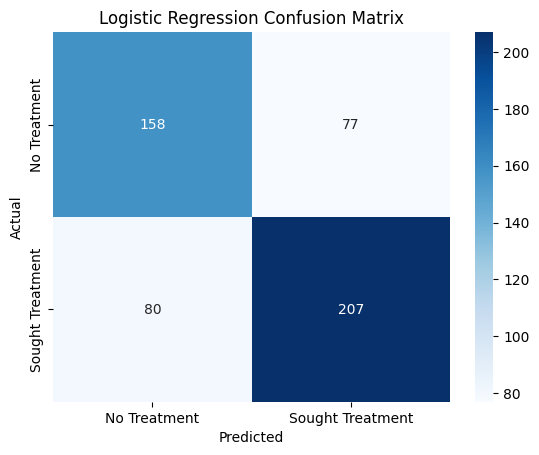

In [71]:
con_mat = confusion_matrix(y_test, y_pred_lr)

ax = sns.heatmap(
    con_mat,
    annot=True,
    cmap='Blues',
    fmt='d',
    xticklabels=['No Treatment', 'Sought Treatment'],
    yticklabels=['No Treatment', 'Sought Treatment']
)

ax.set_title("Logistic Regression Confusion Matrix")
ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")

plt.savefig(
    "workplace-mental-health-risk-prediction/reports/cm_logistic_regression.png",
    dpi=150
)

plt.show()

##K-Nearest Neighbors (KNN)

In [72]:
knn = KNeighborsClassifier(n_neighbors=5)

knn.fit(X_train, y_train)

y_pred_knn = knn.predict(X_test)

print("\nKNN Metrics:")

print("Accuracy:", accuracy_score(y_test, y_pred_knn))
print("Precision:", precision_score(y_test, y_pred_knn))
print("Recall:", recall_score(y_test, y_pred_knn))
print("F1-Score:", f1_score(y_test, y_pred_knn))


KNN Metrics:
Accuracy: 0.6551724137931034
Precision: 0.7034220532319392
Recall: 0.6445993031358885
F1-Score: 0.6727272727272727


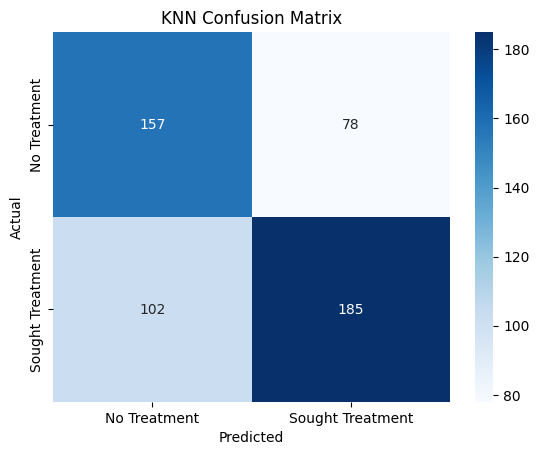

In [74]:
con_mat = confusion_matrix(y_test, y_pred_knn)

ax = sns.heatmap(
    con_mat,
    annot=True,
    cmap='Blues',
    fmt='d',
    xticklabels=['No Treatment', 'Sought Treatment'],
    yticklabels=['No Treatment', 'Sought Treatment']
)

ax.set_title("KNN Confusion Matrix")
ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")

plt.savefig(
    "workplace-mental-health-risk-prediction/reports/cm_knn.png",
    dpi=150
)

plt.show()

##Naive Bayes

In [75]:
nb = GaussianNB()

nb.fit(X_train, y_train)

y_pred_nb = nb.predict(X_test)

print("\nNaive Bayes Metrics:")

print("Accuracy:", accuracy_score(y_test, y_pred_nb))
print("Precision:", precision_score(y_test, y_pred_nb))
print("Recall:", recall_score(y_test, y_pred_nb))
print("F1-Score:", f1_score(y_test, y_pred_nb))


Naive Bayes Metrics:
Accuracy: 0.6340996168582376
Precision: 0.7086956521739131
Recall: 0.5679442508710801
F1-Score: 0.6305609284332688


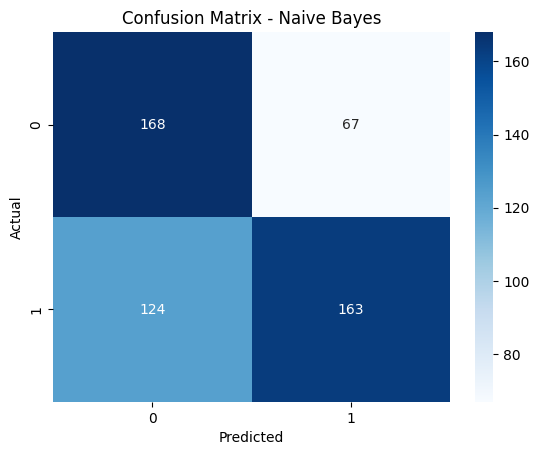

In [76]:
con_mat = confusion_matrix(y_test, y_pred_nb)

ax = sns.heatmap(
    con_mat,
    annot=True,
    cmap='Blues',
    fmt='d'
)

ax.set_title("Confusion Matrix - Naive Bayes")
ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")

plt.savefig(
    "workplace-mental-health-risk-prediction/reports/cm_naive_bayes.png",
    dpi=150
)

plt.show()

## Decision Tree

In [77]:
dt = DecisionTreeClassifier(random_state=42)

dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

print("\nDecision Tree Metrics:")

print("Accuracy:", accuracy_score(y_test, y_pred_dt))
print("Precision:", precision_score(y_test, y_pred_dt))
print("Recall:", recall_score(y_test, y_pred_dt))
print("F1-Score:", f1_score(y_test, y_pred_dt))


Decision Tree Metrics:
Accuracy: 0.603448275862069
Precision: 0.6398601398601399
Recall: 0.6376306620209059
F1-Score: 0.6387434554973822


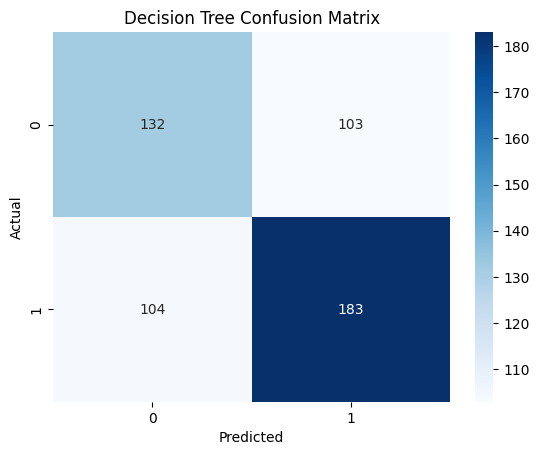

In [78]:
con_mat = confusion_matrix(y_test, y_pred_dt)

ax = sns.heatmap(
    con_mat,
    annot=True,
    cmap='Blues',
    fmt='d'
)

ax.set_title("Decision Tree Confusion Matrix")

ax.set_xlabel("Predicted")

ax.set_ylabel("Actual")

plt.savefig(
    "workplace-mental-health-risk-prediction/reports/cm_decision_tree.png",
    dpi=150
)

plt.show()

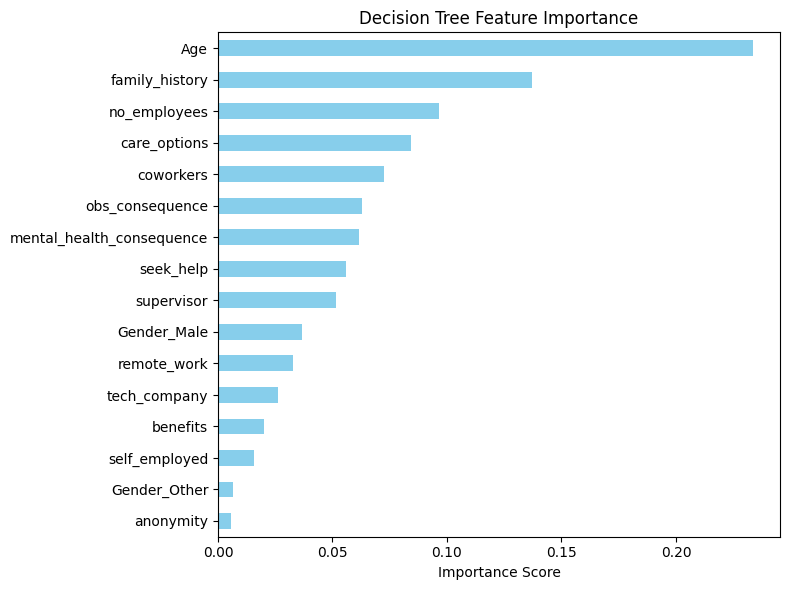

In [79]:
dt_importance = pd.Series(
    dt.feature_importances_,
    index=X_train.columns
)

dt_importance = dt_importance.sort_values()

plt.figure(figsize=(8, 6))

dt_importance.plot(
    kind='barh',
    color='skyblue'
)

plt.title("Decision Tree Feature Importance")
plt.xlabel("Importance Score")

plt.tight_layout()

plt.savefig(
    "workplace-mental-health-risk-prediction/reports/importance_decision_tree.png",
    dpi=150
)

plt.show()

##Random Forest

In [80]:
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print("\nRandom Forest Metrics:")

print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall:", recall_score(y_test, y_pred_rf))
print("F1-Score:", f1_score(y_test, y_pred_rf))


Random Forest Metrics:
Accuracy: 0.6781609195402298
Precision: 0.6950819672131148
Recall: 0.7386759581881533
F1-Score: 0.7162162162162162


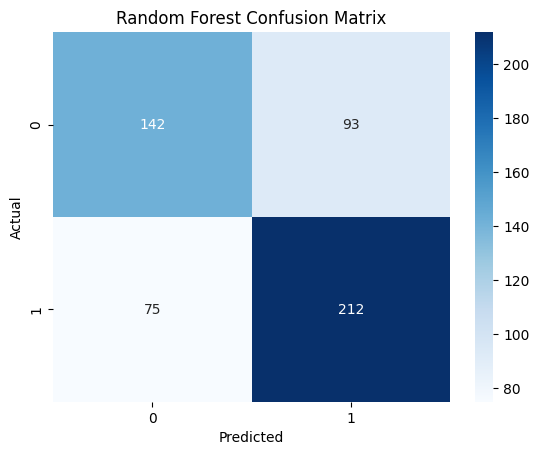

In [81]:
con_mat = confusion_matrix(
    y_test,
    y_pred_rf)

ax = sns.heatmap(
    con_mat,
    annot=True,
    cmap='Blues',
    fmt='d')

ax.set_title("Random Forest Confusion Matrix")
ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")

plt.savefig("workplace-mental-health-risk-prediction/reports/cm_random_forest.png",dpi=150)
plt.show()

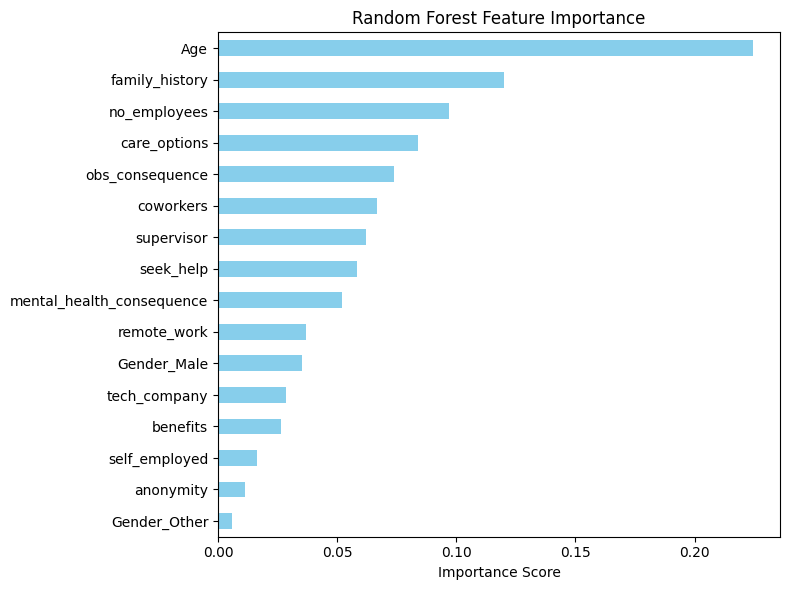


Top 5 Features:
Age                0.224590
family_history     0.120174
no_employees       0.097012
care_options       0.084046
obs_consequence    0.073907
dtype: float64


In [82]:
rf_importance = pd.Series(
    rf.feature_importances_,
    index=X_train.columns).sort_values()

plt.figure(figsize=(8, 6))

rf_importance.plot(
    kind='barh',
    color='skyblue')

plt.title("Random Forest Feature Importance")
plt.xlabel("Importance Score")
plt.tight_layout()
plt.savefig("workplace-mental-health-risk-prediction/reports/importance_random_forest.png",dpi=150)
plt.show()

print("\nTop 5 Features:")

print(
    rf_importance.sort_values(
        ascending=False
    ).head())

##XGBoost

In [83]:
xgb = XGBClassifier(
    n_estimators=100,
    random_state=42,
    eval_metric='logloss',
    verbosity=0)

xgb.fit(X_train, y_train)

y_pred_xgb = xgb.predict(X_test)

print("\nXGBoost Metrics:")

print("Accuracy:", accuracy_score(y_test, y_pred_xgb))
print("Precision:", precision_score(y_test, y_pred_xgb))
print("Recall:", recall_score(y_test, y_pred_xgb))
print("F1-Score:", f1_score(y_test, y_pred_xgb))


XGBoost Metrics:
Accuracy: 0.6819923371647509
Precision: 0.6983606557377049
Recall: 0.7421602787456446
F1-Score: 0.7195945945945946


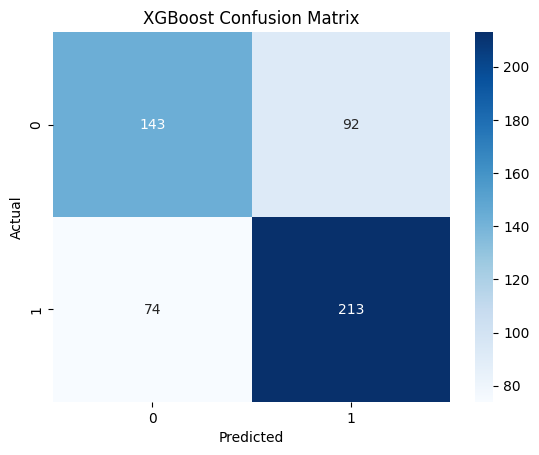

In [84]:
con_mat = confusion_matrix(y_test, y_pred_xgb)

ax = sns.heatmap(
    con_mat,
    annot=True,
    cmap='Blues',
    fmt='d')

ax.set_title("XGBoost Confusion Matrix")

ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")

plt.savefig("workplace-mental-health-risk-prediction/reports/cm_xgboost.png",dpi=150)

plt.show()

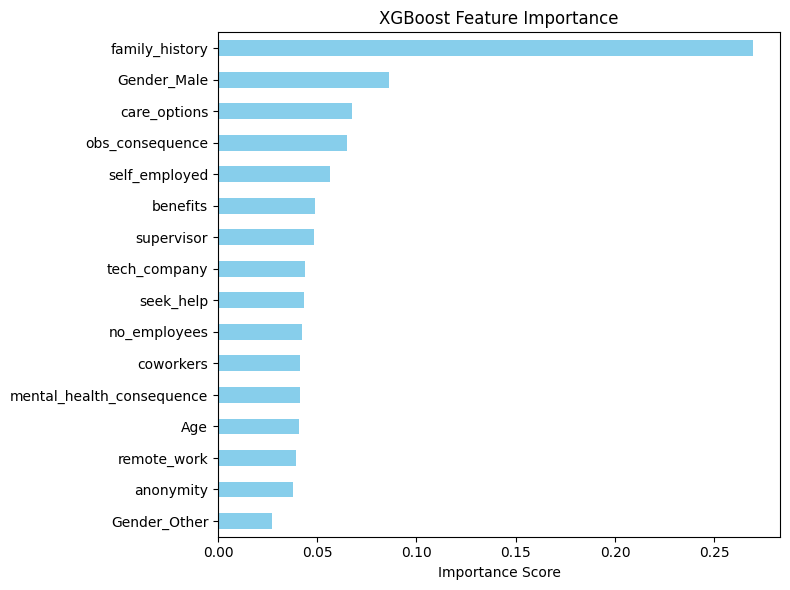

In [85]:
xgb_importance = pd.Series(
    xgb.feature_importances_,
    index=X_train.columns).sort_values()

plt.figure(figsize=(8, 6))

xgb_importance.plot(
    kind='barh',
    color='skyblue')

plt.title("XGBoost Feature Importance")
plt.xlabel("Importance Score")
plt.tight_layout()
plt.savefig("workplace-mental-health-risk-prediction/reports/importance_xgboost.png",dpi=150)

plt.show()

##Model comparison

In [86]:
summary = {
    'Logistic Regression': y_pred_lr,
    'KNN': y_pred_knn,
    'Naive Bayes': y_pred_nb,
    'Decision Tree': y_pred_dt,
    'Random Forest': y_pred_rf,
    'XGBoost': y_pred_xgb
}

print("Model Comparison")

best_recall = 0
best_model = ""

for name, y_pred in summary.items():

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    print("\n", name)
    print("Accuracy:", round(acc, 3))
    print("Precision:", round(prec, 3))
    print("Recall:", round(rec, 3))
    print("F1 Score:", round(f1, 3))

Model Comparison

 Logistic Regression
Accuracy: 0.699
Precision: 0.729
Recall: 0.721
F1 Score: 0.725

 KNN
Accuracy: 0.655
Precision: 0.703
Recall: 0.645
F1 Score: 0.673

 Naive Bayes
Accuracy: 0.634
Precision: 0.709
Recall: 0.568
F1 Score: 0.631

 Decision Tree
Accuracy: 0.603
Precision: 0.64
Recall: 0.638
F1 Score: 0.639

 Random Forest
Accuracy: 0.678
Precision: 0.695
Recall: 0.739
F1 Score: 0.716

 XGBoost
Accuracy: 0.682
Precision: 0.698
Recall: 0.742
F1 Score: 0.72


#Tuning

##Hyperparameter tuning on Logistic Regression

In [87]:
lr_params = {
    'C'      : [0.01, 0.1, 1, 10, 100],
    'solver' : ['lbfgs', 'liblinear'],
    'penalty': ['l2']
}

lr_grid = GridSearchCV(
    LogisticRegression(max_iter=1000, random_state=42),
    lr_params,
    cv=5,
    scoring='recall',
    n_jobs=-1
)

lr_grid.fit(X_train, y_train)
best_lr = lr_grid.best_estimator_
y_pred_lr_tuned = best_lr.predict(X_test)

print("Tuned Logistic Regression:")
print(f"  Best params: {lr_grid.best_params_}")
print(f"  Accuracy : {accuracy_score(y_test, y_pred_lr_tuned):.4f}")
print(f"  Precision: {precision_score(y_test, y_pred_lr_tuned):.4f}")
print(f"  Recall   : {recall_score(y_test, y_pred_lr_tuned):.4f}")
print(f"  F1       : {f1_score(y_test, y_pred_lr_tuned):.4f}")

Tuned Logistic Regression:
  Best params: {'C': 0.01, 'penalty': 'l2', 'solver': 'liblinear'}
  Accuracy : 0.7088
  Precision: 0.7090
  Recall   : 0.7979
  F1       : 0.7508


##Hyperparameter tuning on Random Forest

In [88]:
rf_params = {
    'n_estimators'    : [100, 200, 300],
    'max_depth'       : [None, 10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf' : [1, 2]
}

rf_grid = GridSearchCV(
    RandomForestClassifier(
        random_state=42
    ),
    rf_params,
    cv=5,
    scoring='recall',
    n_jobs=-1,
    verbose=1
)

rf_grid.fit(X_train, y_train)
best_rf = rf_grid.best_estimator_
y_pred_rf_tuned = best_rf.predict(X_test)

print("Tuned Random Forest:")
print(f"  Best params: {rf_grid.best_params_}")
print(f"  Accuracy : {accuracy_score(y_test, y_pred_rf_tuned):.4f}")
print(f"  Precision: {precision_score(y_test, y_pred_rf_tuned):.4f}")
print(f"  Recall   : {recall_score(y_test, y_pred_rf_tuned):.4f}")
print(f"  F1       : {f1_score(y_test, y_pred_rf_tuned):.4f}")

Fitting 5 folds for each of 36 candidates, totalling 180 fits
Tuned Random Forest:
  Best params: {'max_depth': 10, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 300}
  Accuracy : 0.7031
  Precision: 0.7200
  Recall   : 0.7526
  F1       : 0.7359


##Hyperparameter tuning on XGBoost

In [92]:
xgb_params = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.8, 1.0]
}

xgb_grid = GridSearchCV(
    XGBClassifier(
        random_state=42,
        eval_metric='logloss'
    ),
    xgb_params,
    cv=5,
    scoring='recall',
    n_jobs=-1,
    verbose=1
)

xgb_grid.fit(X_train, y_train)

best_xgb = xgb_grid.best_estimator_

y_pred_xgb_tuned = best_xgb.predict(X_test)

print("Tuned XGBoost:")
print(f"  Best params: {xgb_grid.best_params_}")
print(f"  Accuracy : {accuracy_score(y_test, y_pred_xgb_tuned):.4f}")
print(f"  Precision: {precision_score(y_test, y_pred_xgb_tuned):.4f}")
print(f"  Recall   : {recall_score(y_test, y_pred_xgb_tuned):.4f}")
print(f"  F1       : {f1_score(y_test, y_pred_xgb_tuned):.4f}")

Fitting 5 folds for each of 54 candidates, totalling 270 fits
Tuned XGBoost:
  Best params: {'learning_rate': 0.01, 'max_depth': 7, 'n_estimators': 100, 'subsample': 0.8}
  Accuracy : 0.6897
  Precision: 0.6959
  Recall   : 0.7735
  F1       : 0.7327


In [89]:
#After hyperparameter tuning, Logistic Regression achieved 0.798 Recall compared to Random Forest (0.753) and XGBoost (0.774)
#Since our primary metric is Recall — minimising false negatives in a mental health screening context
# Logistic Regression was selected as the final model.

FINAL MODEL - Logistic Regression (Tuned)
Best Parameters
C = 0.01
Penalty = l2
Solver = liblinear

Classification Report

                  precision    recall  f1-score   support

    No Treatment       0.71      0.60      0.65       235
Sought Treatment       0.71      0.80      0.75       287

        accuracy                           0.71       522
       macro avg       0.71      0.70      0.70       522
    weighted avg       0.71      0.71      0.71       522



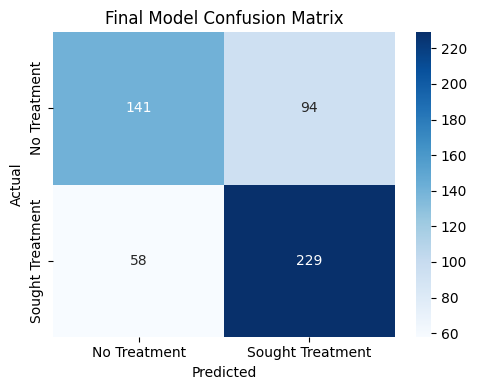

In [94]:
print("FINAL MODEL - Logistic Regression (Tuned)")

print("Best Parameters")
print("C = 0.01")
print("Penalty = l2")
print("Solver = liblinear")

print("\nClassification Report\n")

print(classification_report(
y_test,
y_pred_lr_tuned,
target_names=['No Treatment','Sought Treatment']
))

plt.figure(figsize=(5,4))

sns.heatmap(
confusion_matrix(y_test,y_pred_lr_tuned),
annot=True,
fmt='d',
cmap='Blues',
xticklabels=['No Treatment','Sought Treatment'],
yticklabels=['No Treatment','Sought Treatment'])

plt.title("Final Model Confusion Matrix")

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.tight_layout()

plt.savefig(
"workplace-mental-health-risk-prediction/reports/final_model_cm.png",
dpi=150
)

plt.show()

##Check feature importance

In [93]:
feature_names = X_train.columns

coef_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': best_lr.coef_[0]
})

coef_df['Abs_Coefficient'] = coef_df['Coefficient'].abs()

coef_df.sort_values(
    by='Abs_Coefficient',
    ascending=False
)

,Feature,Coefficient,Abs_Coefficient
10,family_history,0.745397,0.745397
14,Gender_Male,-0.438841,0.438841
6,care_options,0.196168,0.196168
8,anonymity,-0.131824,0.131824
13,obs_consequence,0.129121,0.129121
12,supervisor,-0.112323,0.112323
4,remote_work,0.101614,0.101614
1,self_employed,0.100839,0.100839
7,seek_help,0.083520,0.083520
3,tech_company,-0.077112,0.077112


In [91]:
path = "models/"
os.makedirs(path, exist_ok=True)

path = "models/"
os.makedirs(path, exist_ok=True)

with open(path + "mental_health_model.pkl", "wb") as f:
    pickle.dump(best_lr, f)

with open(path+"ord_enc_social.pkl","wb") as f:
    pickle.dump(ord_enc_social,f)

with open(path+"label_encoders.pkl","wb") as f:
    pickle.dump(label_encoders,f)

with open(path+"onehot_encoder.pkl","wb") as f:
    pickle.dump(ohe,f)

with open(path+"minmax_scaler.pkl","wb") as f:
    pickle.dump(scaler,f)

with open(path + "no_emp_map.pkl", "wb") as f:
    pickle.dump(no_emp_map, f)

print("Saved files:")

for file in os.listdir(path):
    print(file)

Saved files:
minmax_scaler.pkl
label_encoders.pkl
ordinal_encoder.pkl
no_emp_map.pkl
ord_enc_social.pkl
mental_health_model.pkl
onehot_encoder.pkl
